1. Setup and Data Loading

Loaded 100,836 ratings across 610 users and 9724 movies.


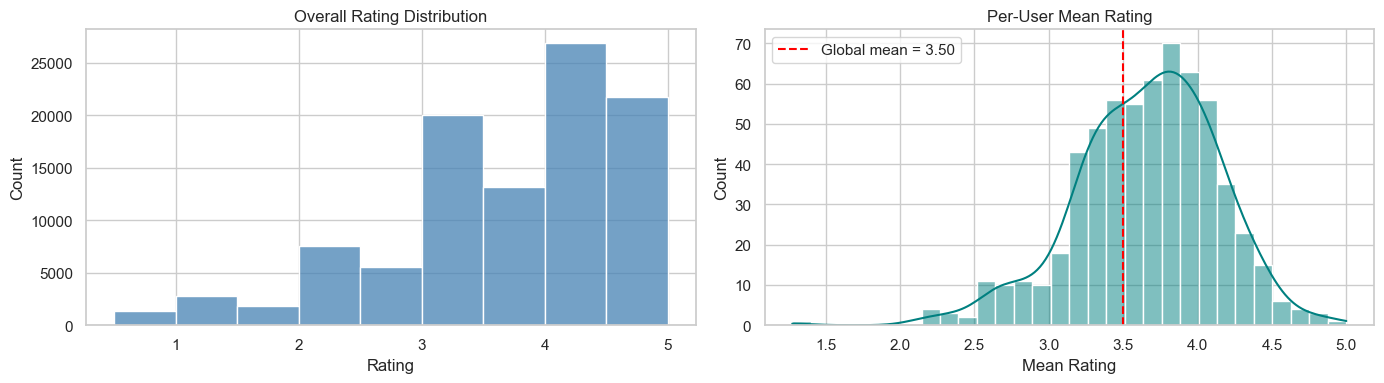

In [11]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
%matplotlib inline

DATA_DIR   = Path('../../dataset')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies  = pd.read_csv(DATA_DIR / 'movies.csv')

print(f'Loaded {len(ratings):,} ratings across {ratings["userId"].nunique()} users and {ratings["movieId"].nunique()} movies.')

# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(ratings['rating'], bins=9, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Rating')

user_means = ratings.groupby('userId')['rating'].mean()
sns.histplot(user_means, bins=30, kde=True, color='teal', ax=axes[1])
axes[1].axvline(ratings['rating'].mean(), color='red', linestyle='--',
                label=f'Global mean = {ratings["rating"].mean():.2f}')
axes[1].set_title('Per-User Mean Rating')
axes[1].set_xlabel('Mean Rating')
axes[1].legend()
plt.tight_layout()
plt.show()

2. Data Engineering & Label Matrix

In [ ]:
movies['genre_list'] = movies['genres'].apply(lambda g: [x for x in g.split('|') if x != '(no genres listed)'])
all_genres = sorted({g for lst in movies['genre_list'] for g in lst})

rated = ratings.merge(movies[['movieId', 'genre_list']], on='movieId', how='left')
rated = rated.explode('genre_list').rename(columns={'genre_list': 'genre'}).dropna(subset=['genre'])

user_genre = rated.groupby(['userId', 'genre'])['rating'].agg(avg='mean', cnt='count').reset_index()
user_ids   = sorted(ratings['userId'].unique())

genre_avg = user_genre.pivot(index='userId', columns='genre', values='avg').reindex(index=user_ids, columns=all_genres).fillna(0)
genre_cnt = user_genre.pivot(index='userId', columns='genre', values='cnt').reindex(index=user_ids, columns=all_genres).fillna(0)

user_mean = ratings.groupby('userId')['rating'].mean()
engaged   = genre_cnt.div(genre_cnt.sum(axis=1).replace(0, 1), axis=0) >= 0.10
quality   = (genre_avg.sub(user_mean, axis=0) > 0) & (genre_cnt >= 2)
Y         = (engaged | quality).astype(int)

print(f'Label matrix: {Y.shape[0]} users x {Y.shape[1]} genres')
print(f'Positive label rate: {Y.values.mean():.2%}')

# Label distribution
label_freq = Y.mean().sort_values(ascending=False)
plt.figure(figsize=(14, 4))
sns.barplot(x=label_freq.index, y=label_freq.values, palette='viridis')
plt.title('Positive Label Rate per Genre (Classification Targets)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraction of Users')
plt.tight_layout()
plt.show()

3. Feature Engineering

In [ ]:
user_stats = ratings.groupby('userId')['rating'].agg(user_mean='mean', user_count='count', user_std='std').fillna(0)

matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
matrix_centred = matrix.values - matrix.values.mean(axis=1, keepdims=True)

svd = TruncatedSVD(n_components=50, random_state=42)
U_sigma = svd.fit_transform(matrix_centred)
svd_df  = pd.DataFrame(U_sigma, index=matrix.index, columns=[f'svd_{i}' for i in range(50)])

X_df = user_stats.join(svd_df, how='left').reindex(user_ids).fillna(0)
print(f'Feature matrix: {X_df.shape} (users x features)')

X_train, X_test, Y_train, Y_test = train_test_split(X_df.values, Y.values, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

4. Visualizing Input Features

In [ ]:
# Global stats distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, ['user_mean', 'user_count', 'user_std'],
                           ['steelblue', 'orange', 'mediumseagreen']):
    sns.histplot(X_df[col], bins=30, kde=True, color=color, ax=ax)
    ax.set_title(col)
plt.suptitle('Global User Stat Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# SVD explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(svd.explained_variance_ratio_)), svd.explained_variance_ratio_, color='cornflowerblue')
axes[0].set_title('SVD: Variance per Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(np.cumsum(svd.explained_variance_ratio_), color='red', marker='o', markersize=3)
axes[1].set_title('SVD: Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
plt.tight_layout()
plt.show()

# First SVD latent feature distribution
plt.figure(figsize=(10, 4))
sns.histplot(X_df['svd_0'], bins=30, kde=True, color='mediumpurple')
plt.title('Distribution of svd_0 (Primary Latent Taste Feature)')
plt.xlabel('Feature Value')
plt.tight_layout()
plt.show()

print('Raw Input Feature Sample (First 10 Users)')
display(X_df.iloc[:10, :10].style.background_gradient(cmap='coolwarm', axis=0).format('{:.3f}'))

5. Logistic Regression

In [ ]:
print('Training Logistic Regression...')
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000), n_jobs=-1)
lr_model.fit(X_train, Y_train)
lr_preds = lr_model.predict(X_test)

lr_f1 = f1_score(Y_test, lr_preds, average='micro', zero_division=0)
lr_hl = hamming_loss(Y_test, lr_preds)
print(f'Logistic Regression  F1={lr_f1:.4f}  HammingLoss={lr_hl:.4f}')

# Per-genre F1
lr_per_genre = f1_score(Y_test, lr_preds, average=None, zero_division=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(x=all_genres, y=lr_per_genre, color='steelblue', ax=axes[0])
axes[0].set_title('Logistic Regression — F1 per Genre')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')

imp = np.abs(lr_model.estimators_[0].coef_).flatten()
top15 = pd.Series(imp, index=X_df.columns).sort_values(ascending=False).head(15)
sns.barplot(x=top15.values, y=top15.index, palette='rocket', ax=axes[1])
axes[1].set_title('Logistic Regression — Top 15 Features (|coef|)')
plt.tight_layout()
plt.show()

6. Random Forest

In [ ]:
print('Training Random Forest...')
rf_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1), n_jobs=-1)
rf_model.fit(X_train, Y_train)
rf_preds = rf_model.predict(X_test)

rf_f1 = f1_score(Y_test, rf_preds, average='micro', zero_division=0)
rf_hl = hamming_loss(Y_test, rf_preds)
print(f'Random Forest  F1={rf_f1:.4f}  HammingLoss={rf_hl:.4f}')

rf_per_genre = f1_score(Y_test, rf_preds, average=None, zero_division=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(x=all_genres, y=rf_per_genre, color='mediumseagreen', ax=axes[0])
axes[0].set_title('Random Forest — F1 per Genre')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')

imp = rf_model.estimators_[0].feature_importances_
top15 = pd.Series(imp, index=X_df.columns).sort_values(ascending=False).head(15)
sns.barplot(x=top15.values, y=top15.index, palette='rocket', ax=axes[1])
axes[1].set_title('Random Forest — Top 15 Features')
plt.tight_layout()
plt.show()

7. XGBoost

In [ ]:
print('Training XGBoost...')
xgb_model = MultiOutputClassifier(XGBClassifier(n_estimators=100, eval_metric='logloss', verbosity=0), n_jobs=-1)
xgb_model.fit(X_train, Y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_f1 = f1_score(Y_test, xgb_preds, average='micro', zero_division=0)
xgb_hl = hamming_loss(Y_test, xgb_preds)
print(f'XGBoost  F1={xgb_f1:.4f}  HammingLoss={xgb_hl:.4f}')

xgb_per_genre = f1_score(Y_test, xgb_preds, average=None, zero_division=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(x=all_genres, y=xgb_per_genre, color='mediumpurple', ax=axes[0])
axes[0].set_title('XGBoost — F1 per Genre')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')

imp = xgb_model.estimators_[0].feature_importances_
top15 = pd.Series(imp, index=X_df.columns).sort_values(ascending=False).head(15)
sns.barplot(x=top15.values, y=top15.index, palette='rocket', ax=axes[1])
axes[1].set_title('XGBoost — Top 15 Features')
plt.tight_layout()
plt.show()

8. Model Comparison

In [ ]:
perf_data = {
    'Logistic Regression': (lr_f1,  lr_hl,  lr_per_genre),
    'Random Forest':       (rf_f1,  rf_hl,  rf_per_genre),
    'XGBoost':             (xgb_f1, xgb_hl, xgb_per_genre),
}
perf_df = pd.DataFrame([
    {'Model': name, 'F1-Micro': f1, 'Hamming Loss': hl}
    for name, (f1, hl, _) in perf_data.items()
]).set_index('Model')

# Bar charts
colors = ['steelblue', 'mediumseagreen', 'mediumpurple']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, better in zip(axes, ['F1-Micro', 'Hamming Loss'], ['Higher', 'Lower']):
    bars = ax.bar(perf_df.index, perf_df[metric], color=colors)
    for bar, val in zip(bars, perf_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{metric} ({better} is Better)')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

# Per-genre F1 comparison
genre_f1_df = pd.DataFrame(
    {name: pg for name, (_, _, pg) in perf_data.items()},
    index=all_genres
)
genre_f1_df.plot(kind='bar', figsize=(16, 5), color=colors)
plt.title('F1 per Genre — All Models')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1 Score')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model':          ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Type':           ['Linear', 'Ensemble (Bagging)', 'Ensemble (Boosting)'],
    'F1-Micro':       perf_df['F1-Micro'].values.round(4),
    'Hamming Loss':   perf_df['Hamming Loss'].values.round(4),
})
display(summary)
best = perf_df['F1-Micro'].idxmax()
print(f'\nBest model: {best} (F1-Micro = {perf_df.loc[best, "F1-Micro"]:.4f})')